## PROJECT - AIRLINE AI ASSISTANT

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline.

In [18]:
import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
from rich import print
import sqlite3

In [82]:
load_dotenv(override=True)
groq_api_key = os.getenv("GROQ_API_KEY")
groq_model = os.getenv("GROQ_MODEL") or "openai/gpt-oss-20b"
groq_base_url = os.getenv("GROQ_BASE_URL")

if groq_api_key:
    print(f"GROQ API Key exists and begins {groq_api_key[:8]}")
else:
    print("GROQ API Key not set")

GROQ API Key exists and begins gsk_GIUx

In [83]:
openai = OpenAI(base_url=groq_base_url, api_key=groq_api_key)

In [3]:
db = "prices.db"

In [4]:
system_message = """
You are a helpful assistant for an Airline called "Akasa Air".
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [7]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(db) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [8]:
get_ticket_price("Delhi")

DATABASE TOOL CALLED: Getting price for Delhi


'Ticket price to Delhi is $₹4000'

In [9]:
# There's a particular dictionary structure that's required to describe our function.

price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination": {
                "type": "string",
                "description": "The city that the customer wants to travel to."
            }
        },
        "required": ["destination"],
        "additionalProperties": False
    }
}

In [10]:
tools = [{"type": "function", "function": price_function}]

In [12]:
def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=groq_model, messages=messages)
    return response.choices[0].message.content

In [13]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7874
* To create a public link, set `share=True` in `launch()`.


In [41]:
def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=groq_model, messages=messages, tools=tools)
    
    print(f"[green]response after tool_calls[/green]:\n\n {response}")

    if response.choices[0].finish_reason == "tool_calls":
        tool_call = response.choices[0].message.tool_calls[0]

        if tool_call.type == "function" and tool_call.function.name == "get_ticket_price":

            # parse the json string from .function.arguments
            tool_args = json.loads(tool_call.function.arguments)
            destination = tool_args.get("destination")

            tool_response = get_ticket_price(destination)

            # pass the tool response back to the message history
            messages.append({"role": "tool", 
                             "tool_call_id": tool_call.id,
                             "name": tool_call.function.name,
                             "content": str(tool_response)})
            
            
            final_response = openai.chat.completions.create(model=groq_model, messages=messages)
            print(f"[green]final_response[/green]:\n\n {final_response}")
            return final_response.choices[0].message.content
    else:
        return response.choices[0].message.content

In [42]:
chat("What is the price of a ticket to Delhi?", [])

response after tool_calls:

 ChatCompletion(id='chatcmpl-67b4d54c-516a-4114-a146-54e918732bc5', choices=[Choice(finish_reason='tool_calls', 
index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', 
annotations=None, audio=None, function_call=None, 
tool_calls=[ChatCompletionMessageFunctionToolCall(id='fc_8d8517f0-00e1-420b-962d-288afc3f5b02', 
function=Function(arguments='{"destination":"Delhi"}', name='get_ticket_price'), type='function')], reasoning='We 
need to use the function get_ticket_price. The user asks price to Delhi. Use function.'))], created=1781457486, 
model='openai/gpt-oss-20b', object='chat.completion', service_tier='on_demand', system_fingerprint='fp_c5a89987dc',
usage=CompletionUsage(completion_tokens=45, prompt_tokens=196, total_tokens=241, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=None, 
reasoning_tokens=21, rejected_prediction_tokens=None), prompt_tokens_details=None, queue_time=0.043911517, 
prompt_time=0.009652032, completion_time=0.046442716, total_time=0.056094748), usage_breakdown=None, x_groq={'id': 
'req_01kv3j80ytfg48v5p1785b01rn', 'seed': 325224247})

DATABASE TOOL CALLED: Getting price for Delhi

final_response:

 ChatCompletion(id='chatcmpl-e05ea5ff-6651-4979-aad1-d949a87638d2', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='The ticket price to Delhi is ₹4000.', refusal=None, 
role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning='The system says 
always give short courteous answer no more than 1 sentence. Already have answer from function. We should comply 
with developer instructions. We should provide answer: "The ticket price to Delhi is ₹4000." Ensure short 
courteous.'))], created=1781457487, model='openai/gpt-oss-20b', object='chat.completion', service_tier='on_demand',
system_fingerprint='fp_80501ff3a1', usage=CompletionUsage(completion_tokens=68, prompt_tokens=144, 
total_tokens=212, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, 
audio_tokens=None, reasoning_tokens=49, rejected_prediction_tokens=None), prompt_tokens_details=None, 
queue_time=0.046276409, prompt_time=0.00805328, completion_time=0.078702776, total_time=0.086756056), 
usage_breakdown=None, x_groq={'id': 'req_01kv3j816hfg5s9vtcqxqx9jdd', 'seed': 1477164861})

'The ticket price to Delhi is ₹4000.'

In [43]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7875
* To create a public link, set `share=True` in `launch()`.


response after tool_calls:

 ChatCompletion(id='chatcmpl-326ddce4-2093-42c7-b093-8ec5b206eca3', choices=[Choice(finish_reason='tool_calls', 
index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', 
annotations=None, audio=None, function_call=None, 
tool_calls=[ChatCompletionMessageFunctionToolCall(id='fc_005732a1-a68c-4900-bc1f-b47890d76246', 
function=Function(arguments='{"destination":"Delhi"}', name='get_ticket_price'), type='function')], reasoning='We 
need to use the function get_ticket_price with destination "Delhi". The instruction: always be accurate, no more 
than 1 sentence. The tool is available. Use function call.'))], created=1781457551, model='openai/gpt-oss-20b', 
object='chat.completion', service_tier='on_demand', system_fingerprint='fp_3d587a02fb', 
usage=CompletionUsage(completion_tokens=62, prompt_tokens=203, total_tokens=265, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=None, 
reasoning_tokens=38, rejected_prediction_tokens=None), prompt_tokens_details=None, queue_time=0.045667743, 
prompt_time=0.009833487, completion_time=0.063790415, total_time=0.073623902), usage_breakdown=None, x_groq={'id': 
'req_01kv3j9zrhffjsd3brydsg37me', 'seed': 528712459})

DATABASE TOOL CALLED: Getting price for Delhi

final_response:

 ChatCompletion(id='chatcmpl-304062c9-c87d-4250-9faa-e7155932398e', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='The ticket price to Delhi with Akasa Air is ₹4000.', 
refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning='We 
need to provide answer. The function returned $₹4000. So say ticket price is ₹4000. Use short sentence, no more 
than 1 sentence.'))], created=1781457551, model='openai/gpt-oss-20b', object='chat.completion', 
service_tier='on_demand', system_fingerprint='fp_3d587a02fb', usage=CompletionUsage(completion_tokens=58, 
prompt_tokens=151, total_tokens=209, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=None, 
reasoning_tokens=35, rejected_prediction_tokens=None), prompt_tokens_details=None, queue_time=0.044765671, 
prompt_time=0.007336909, completion_time=0.059251952, total_time=0.066588861), usage_breakdown=None, x_groq={'id': 
'req_01kv3j9zznfv9sxgc0xcwe10h3', 'seed': 953474469})

response after tool_calls:

 ChatCompletion(id='chatcmpl-578ade1d-86c4-4395-a458-21932cdaa64a', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='I’m sorry, I only have ticket price information for Akasa 
Air.', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, 
reasoning='The user asks for ticket price to Delhi for Indigo. We can only provide info for Akasa Air. The 
instructions: "Give short, courteous answers, no more than 1 sentence. Always be accurate. If you don\'t know the 
answer, say so." The user asks about Indigo, but we only know Akasa Air. So we should say we don\'t know or that we
only have Akasa Air info. We could say "I don\'t have price info for Indigo." That satisfies.'))], 
created=1781457565, model='openai/gpt-oss-20b', object='chat.completion', service_tier='on_demand', 
system_fingerprint='fp_c5a89987dc', usage=CompletionUsage(completion_tokens=123, prompt_tokens=243, 
total_tokens=366, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, 
audio_tokens=None, reasoning_tokens=99, rejected_prediction_tokens=None), prompt_tokens_details=None, 
queue_time=0.045432812, prompt_time=0.011850757, completion_time=0.127163986, total_time=0.139014743), 
usage_breakdown=None, x_groq={'id': 'req_01kv3jadhvfm18tpf9rgjr5efa', 'seed': 1073345219})

#### IMAGE GENERATION

In [44]:
# Imports for handling image generations

import base64
from io import BytesIO
from PIL import Image

In [45]:
# function to generate an image from a prompt

def artist(city):
    img_response = openai.images.generate(
        model="groq/dalle-mini",
        prompt=f"An airplane flying over {city} in a futuristic style",
        size="1024x1024",
        n=1,
        response_format="b64_json"
    )

    # decode the base64 image
    image_b64 = img_response.data[0].b64_json
    image_bytes = base64.b64decode(image_b64)
    return Image.open(BytesIO(image_bytes))

In [46]:
image = artist("Bengaluru")
display(image)

NotFoundError: Error code: 404 - {'error': {'message': 'Unknown request URL: POST /openai/v1/images/generations. Please check the URL for typos, or see the docs at https://console.groq.com/docs/', 'type': 'invalid_request_error', 'code': 'unknown_url'}}

In [69]:
# Text-to-speech generation

def talker(message):
    response = openai.audio.speech.create(
        model="canopylabs/orpheus-v1-english",
        voice="hannah",
        input=message,
        response_format="wav"
    )
    return response.content

In [70]:
# Test the function
audio_output = talker("Ujjwal, you are going to become a millionaire, this year and you are going to buy TATA Harrier this year. You are going to gift this beautiful car to your beautiful lovely wife Daminee.")
print("Success! Audio bytes generated.")

Success! Audio bytes generated.

In [71]:
with open("speech.wav", "wb") as f:
    f.write(audio_output)

In [72]:
from IPython.display import Audio, display

# Play the file you just saved
display(Audio("speech.wav", autoplay=False))

#### IMAGE GENERATION WITH AUDIO GENERATION DESCRIBING THE IMAGE

In [74]:
def chat(history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]

    messages = [{"role": "system", "content": system_message}] + history

    response = openai.chat.completions.create(model=groq_model, messages=messages, tools=tools)

    cities = []
    image = None

    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)

        messages.append(message)
        messages.extend(responses)

        response = openai.chat.completions.create(model=groq_model, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assitant", "content":reply }]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])

    return history, voice, image

In [75]:
def handle_tool_call_and_return_cities(message):
    responses = []
    cities = []

    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            tool_args = json.loads(tool_call.function.arguments)
            destination = tool_args.get("destination")
            cities.append(destination)

            tool_response = get_ticket_price(destination)

            responses.append({"role": "tool", 
                             "tool_call_id": tool_call.id,
                             "name": tool_call.function.name,
                             "content": str(tool_response)})
    
    return responses, cities

#### THE 3 TYPES OF GRADIO UI

* `gr.Interface` is for standard, simple UIs.

* `gr.ChatInterface` is for standard ChatBot UIs.

* `gr.Blocks` is for custom UIs where you control the components and the callbacks.

In [77]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
    return "", history + [{"role": "user", "content": message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=400, type="messages")
        image_output = gr.Image(height=400, interactive=False)

    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI assistant")
    
# Hooking up events to callbacks
    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(auth=("ujjwal", "Hanuman"))

C:\Users\Ujjwal Singh\AppData\Local\Temp\ipykernel_23196\1668051930.py:10: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=400, type="messages")


* Running on local URL:  http://127.0.0.1:7877
* To create a public link, set `share=True` in `launch()`.


### SPECIAL EXTRA

Getting the best models on the planet to generate an SVG.

Inspired by the legendary `Simon Willison's` Pelican `riding a bike test`.

`Key point:` This is a very different task to image generation! The model needs to describe the image with lines and shapes.

##### This uses OpenRouter.ai so that we easily access the latest models.

In [80]:
from dotenv import load_dotenv
from IPython.display import Markdown, display
from datetime import datetime
import time
from revealer import reveal
from openai import OpenAI
import os


In [81]:
load_dotenv(override=True)

True

In [90]:
!uv pip show revealer

Using Python 3.12.12 environment at: d:\ujjwal\engineering_llm\.venv


In [84]:
challenge = "a panda rollerblading to work"
prompt = f"Generate an SVG of {challenge}. Respond with the SVG only, no code blocks."
messages = [{"role": "user", "content": prompt}]

In [85]:
def artist(model, effort=None):
    try:
        start = datetime.now()
        response = openai.chat.completions.create(model=model, messages=messages, reasoning_effort=effort)
        result = response.choices[0].message.content
        end = datetime.now()
        elapsed = (end - start).total_seconds()
        heading = f"### {model}\n**Time:** {elapsed // 60:.0f} min {elapsed % 60:.0f} s\n\n"
    except Exception as e:
        print(f"Model {model} failed: {e}")
        heading = f"### {model}\n**Error:** {e}\n\n"
        return heading, None
    return heading, result

In [88]:
results = [
    artist(groq_model),
]

### openai/gpt-oss-20b
**Time:** 0 min 2 s



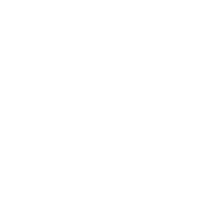

In [89]:
for result in results:
    try:
        display(Markdown(result[0]))
        reveal(result[1])
        time.sleep(12)
    except Exception as e:
        print(f"Error displaying result: {e}")